In [467]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [468]:
ENV_NAMES = (
    "CartPoleContinuous-v1",
    "Pendulum-v1",
    "MountainCarContinuous-v0",
    "LunarLanderContinuous-v3",
)
PROPORTIONS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
EVAL_INTERVAL = 100
INPUT_DIR = "../results/all_performances-" + "selected"

In [469]:
all_performances = {}
for env_name in ENV_NAMES:
    best_performance = -np.inf
    all_performances[env_name] = {}
    best_path = None 
    for best_path in glob.glob(f"{INPUT_DIR}/all-run-{env_name}-best-*"):
        curr_performance = float(best_path.split("-best-")[1])
        if curr_performance > best_performance:
            best_performance = curr_performance
            all_performances[env_name][best_performance] = torch.load(best_path, weights_only=False)
    print(f"{env_name}:")
    print(f"    {best_performance}")
    
    for intermediate_path in glob.glob(f"{INPUT_DIR}/all-run-{env_name}-intermediate-*"):
        exploit_performance = float(intermediate_path.split("-intermediate-")[1])
        print(f"    {exploit_performance}")
        all_performances[env_name][exploit_performance] = torch.load(intermediate_path, weights_only=False)

CartPoleContinuous-v1:
    500.0
    500.0
    129.0
    439.0
    293.0
Pendulum-v1:
    -145.0
    -479.0
    -233.0
    -958.0
    -742.0
MountainCarContinuous-v0:
    95.0
    61.0
    35.0
LunarLanderContinuous-v3:
    186.0
    174.0


In [470]:
def smooth(x, window, mode="gaussian"):
    if window % 2 == 0:
        raise ValueError("Window size must be odd")

    radius = window // 2

    if mode == "gaussian":
        sigma = (window - 1) / 6  # key conversion

        t = np.arange(-radius, radius + 1)
        kernel = np.exp(-(t**2) / (2 * sigma**2))
        kernel /= kernel.sum()

        return np.convolve(x, kernel, mode="valid")

    elif mode == "max":
        return np.array([
            np.max(x[i:i+window])
            for i in range(len(x) - window + 1)
        ])

    else:
        raise ValueError("Unknown mode")
        

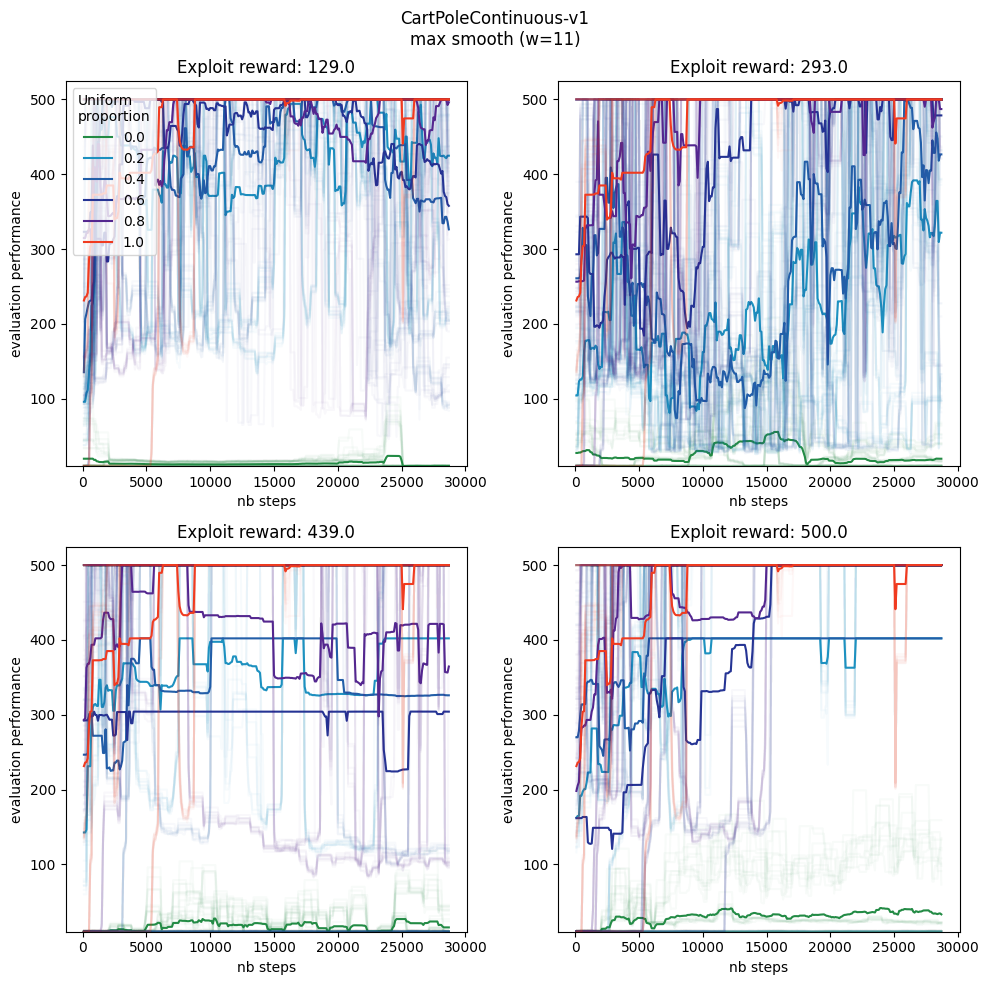

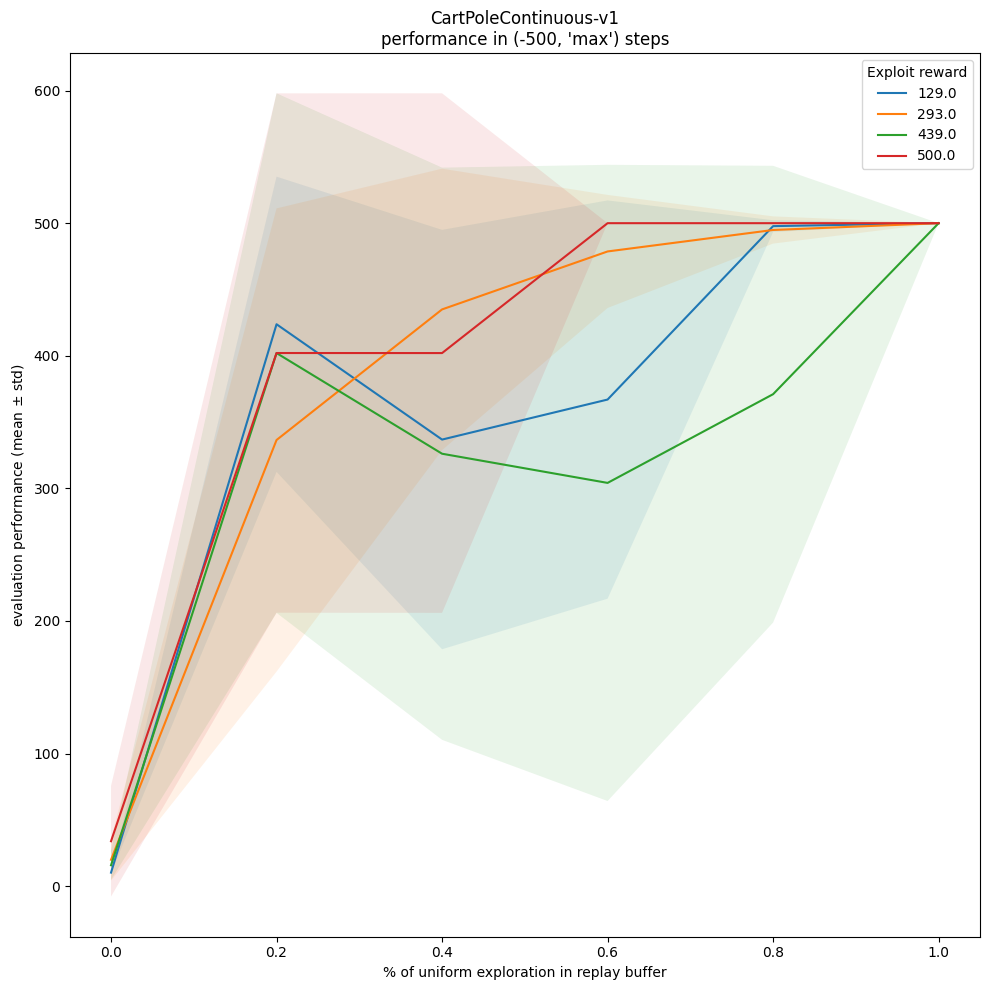

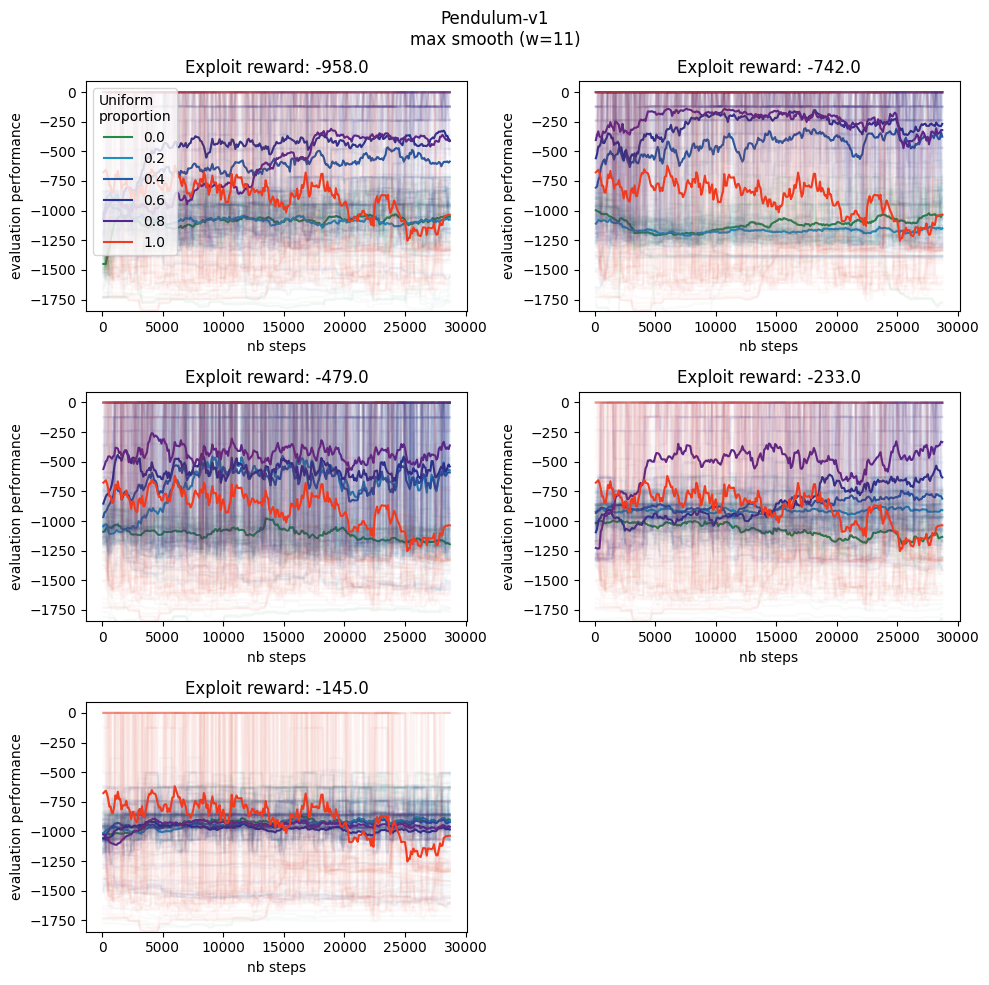

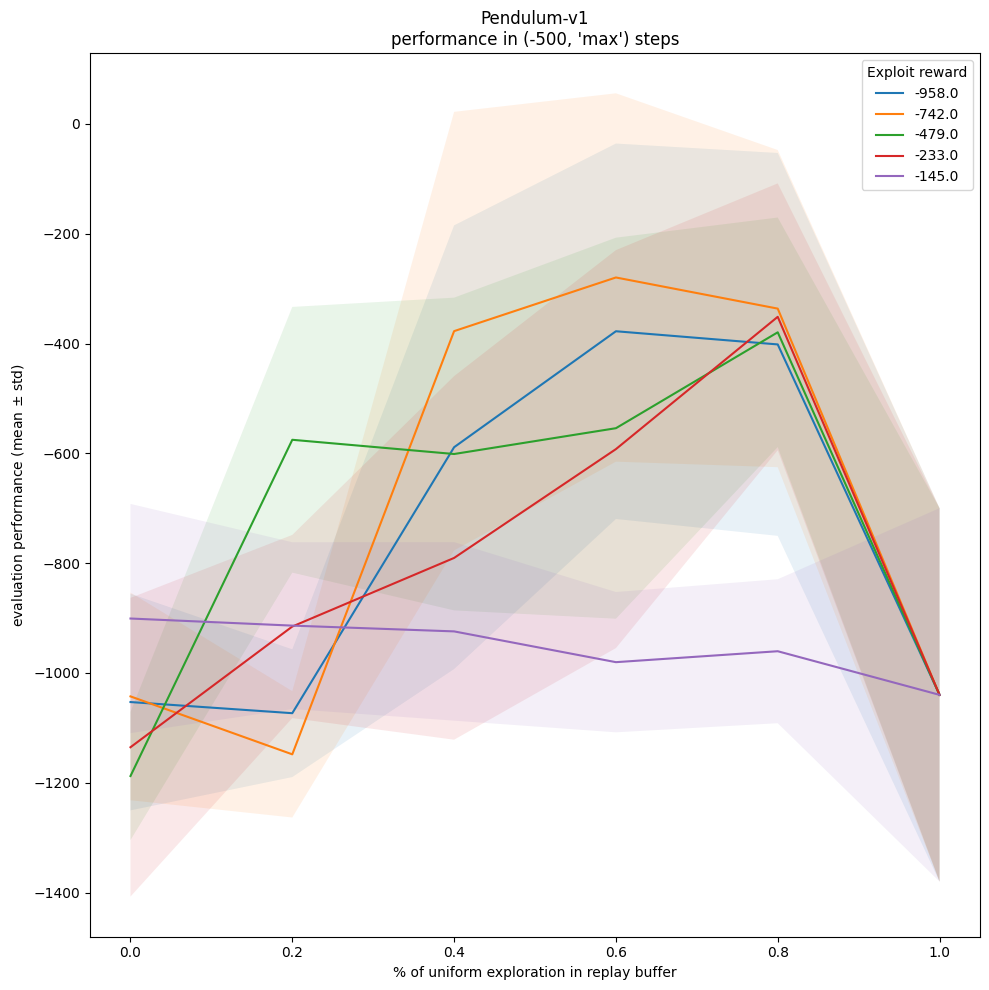

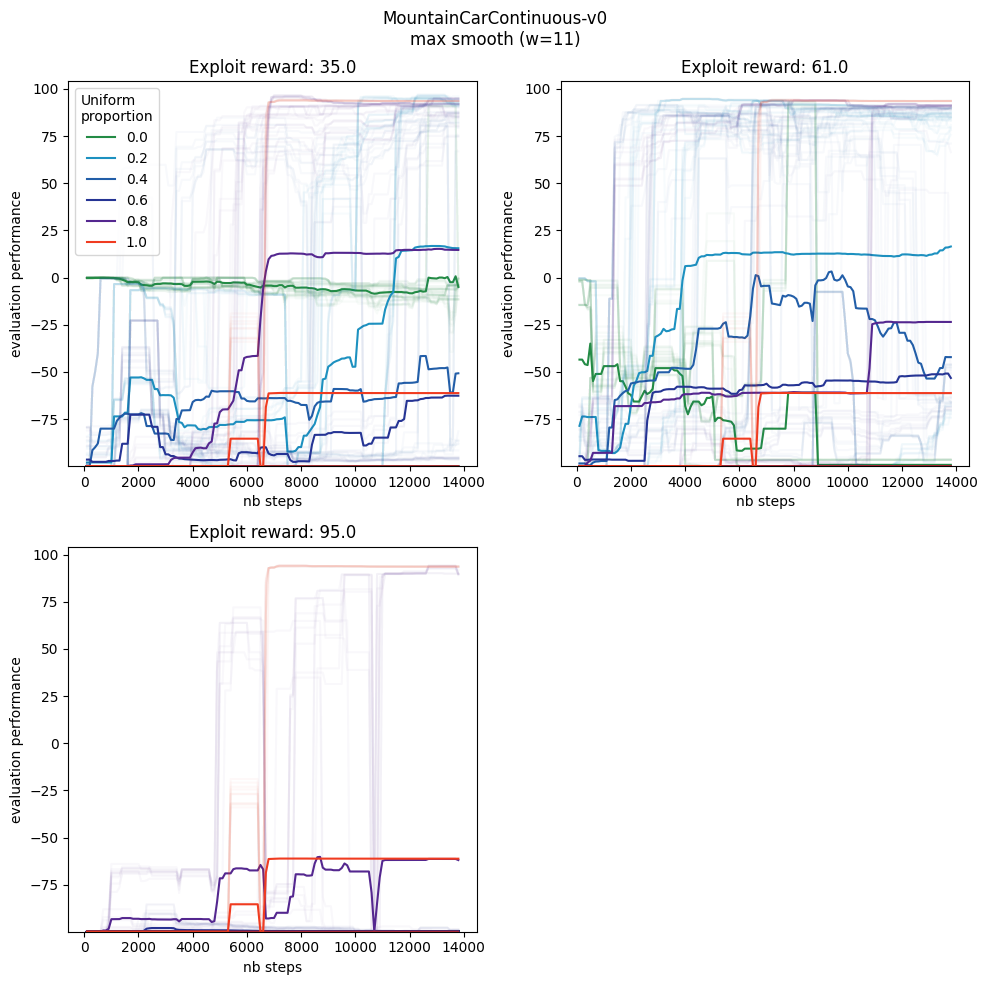

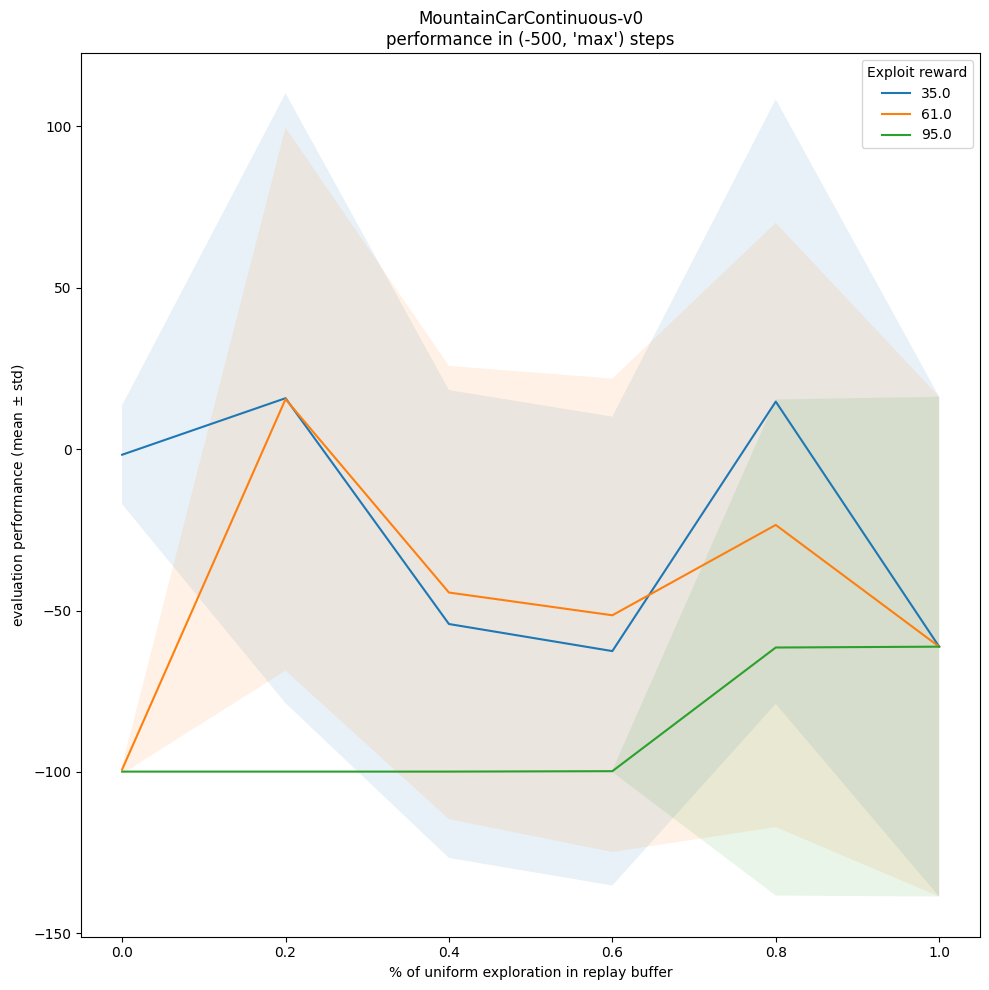

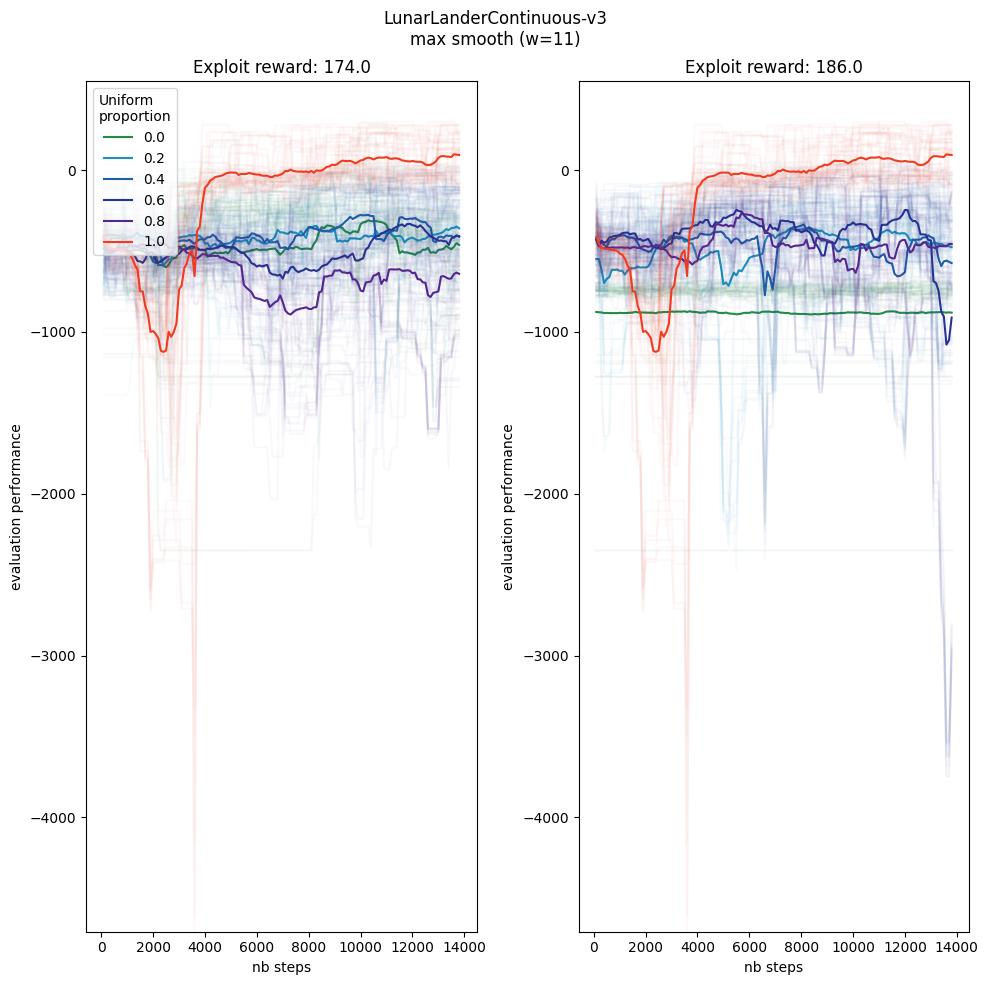

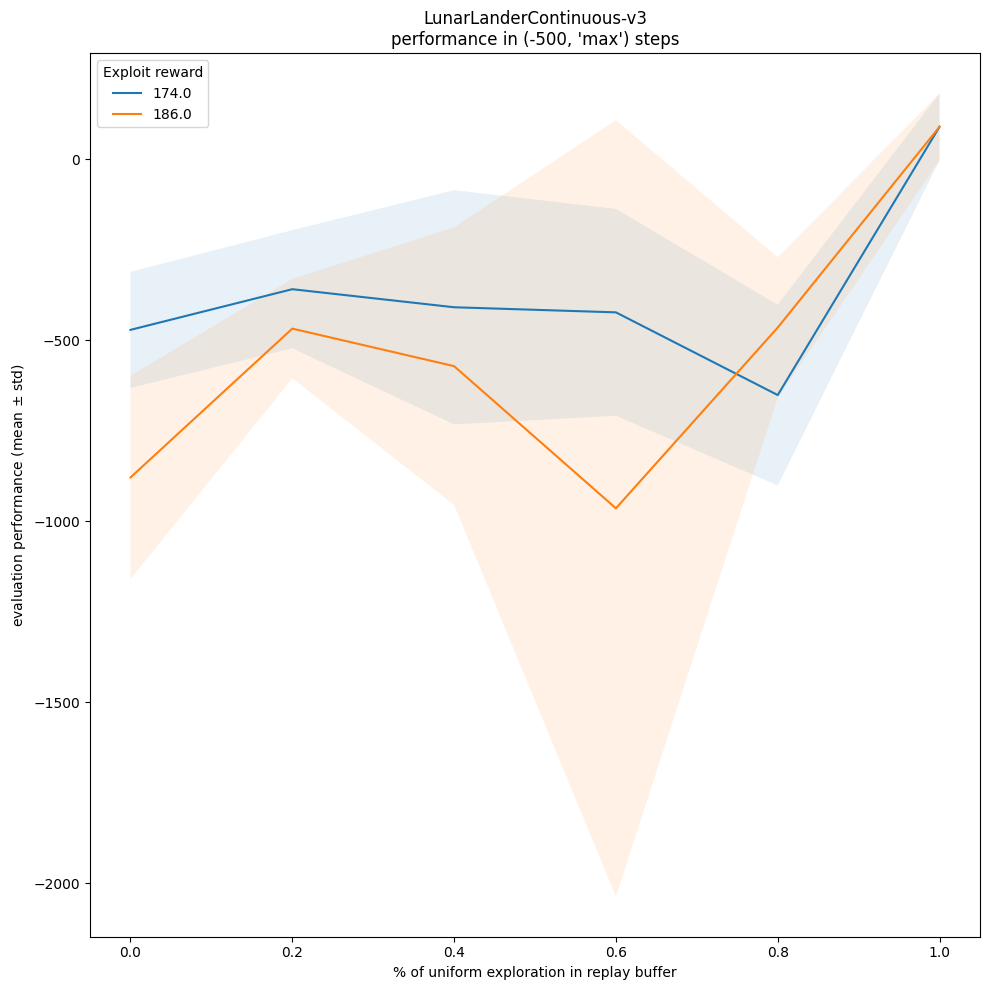

In [472]:
colors = [
"#238b45",  
"#1d91c0",  
"#225ea8",  
"#253494",  
"#54278f",  
"#f03b20"   
]

SMOOTH = True
SMOOTH_WINDOW = 11
SMOOTH_MODE = ("gaussian", "max")[1]
PLOT_ALL_CURVES = True
STEP_TO_TAKE = None#15_000
LAST_STEPS = 500

last_performances = {}
std_last_performances = {}

for env_name in ENV_NAMES:
    if not all_performances[env_name]:
        continue
    
    last_performances[env_name] = {}
    std_last_performances[env_name] = {}
    
    # Learning curves ==========================
    if len(all_performances[env_name]) == 1:
        ncols = 1
    else:
        ncols = 2
    fig, axes = plt.subplots(int(np.ceil(len(all_performances[env_name])/ncols)), ncols, figsize=(10,10))
    if ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for i_reward, reward in enumerate(sorted(all_performances[env_name])):
        last_performances[env_name][reward] = np.zeros(len(PROPORTIONS))
        std_last_performances[env_name][reward] = np.zeros(len(PROPORTIONS))
        # List by proportion of arrays EVAL_NUM x ENV x SEED
        performances = all_performances[env_name][reward] 
        for i_prop, proportion in enumerate(PROPORTIONS):
            nb_evals, nb_envs, nb_seeds = performances[0].shape
            if SMOOTH:
                learning_curves = np.empty( (nb_evals - SMOOTH_WINDOW+1, nb_envs,nb_seeds) )
            else:
                learning_curves = np.empty( (nb_evals, nb_envs,nb_seeds) )
            for i_env in range(performances[0].shape[1]):
                for i_seed in range(performances[0].shape[2]):
                    learning_curve = performances[i_prop][:,i_env,i_seed]
                    if SMOOTH:
                        learning_curve = smooth(learning_curve, window=SMOOTH_WINDOW, mode=SMOOTH_MODE)
                    learning_curves[:,i_env,i_seed] = learning_curve
                    label = proportion if i_seed == 0 and i_env == 0 else None
                    if PLOT_ALL_CURVES:
                        axes[i_reward].plot((np.arange(len(learning_curve))+1)*EVAL_INTERVAL,learning_curve, color = colors[i_prop], alpha=0.03) # label = label
            # NOTE: Choose aggregation: first on ENV and then on SEED dimension
            aggregated_learning_curves = learning_curves.mean(1).mean(1)
            std_learning_curves = learning_curves.mean(1).std(1)
            if STEP_TO_TAKE is not None:
                step_slice = slice((STEP_TO_TAKE - LAST_STEPS) // EVAL_INTERVAL , STEP_TO_TAKE // EVAL_INTERVAL)
            else:
                step_slice = slice(- LAST_STEPS // EVAL_INTERVAL, None)
                
            
            last_performances[env_name][reward][i_prop] = aggregated_learning_curves[step_slice].mean()
            std_last_performances[env_name][reward][i_prop]= std_learning_curves[step_slice].mean() # TODO: better std pooling
            
            axes[i_reward].plot((np.arange(len(learning_curves))+1)*EVAL_INTERVAL, aggregated_learning_curves, color = colors[i_prop], label=proportion, alpha=1)
            
            min_perf, max_perf = learning_curves.min(), learning_curves.max()
            axes[i_reward].set_ylim([ min_perf, max_perf + 0.05 * (max_perf - min_perf) ])
        axes[i_reward].set_title(f"Exploit reward: {reward}")
        axes[i_reward].set_ylabel("evaluation performance")
        axes[i_reward].set_xlabel("nb steps")
    for ax in axes[i_reward+1:]:
        fig.delaxes(ax)
    axes[0].legend(title="Uniform\nproportion", loc = "upper left")
    fig.suptitle(f"{env_name}"+f"\n{SMOOTH_MODE} smooth (w={SMOOTH_WINDOW})" if SMOOTH else "")
    plt.tight_layout()
    plt.show()
    
    # Performance ~ RB composition =====================================

    plt.figure(figsize=(10,10))
    for i_reward, reward in enumerate(sorted(all_performances[env_name])):
        performances =  all_performances[env_name][reward]
        means = last_performances[env_name][reward]
        stds = std_last_performances[env_name][reward]
        plt.plot(PROPORTIONS, means, label=reward)
        plt.fill_between(
            PROPORTIONS,
            means - stds,
            means + stds,
            alpha=0.1,
        )

    plt.title(f"{env_name}\nperformance in { step_slice.start * EVAL_INTERVAL, step_slice.stop * EVAL_INTERVAL if step_slice.stop is not None else 'max'} steps")
    plt.xlabel("% of uniform exploration in replay buffer")
    plt.ylabel("evaluation performance (mean $\\pm$ std)")
    plt.legend(title="Exploit reward")
    plt.tight_layout()
    plt.show()
